# Numerical Project 2b (CIR Model)

In this project, we simulate the Cox-Ingersoll-Ross (CIR) model

$$
dX_t = (a-X_t)\,dt + \sqrt{X_t}\,dB_t, \qquad X_0 = 1
$$

using a time discretization of \(0.001\).

We first plot 10 sample paths for three values of the parameter \(a\), then simulate 1000 paths and compute the proportion of paths that become negative.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

## Euler simulation of the CIR model

In [2]:
def CIR(a, interval, step):

    n = int(interval/step)

    X = [1]

    for i in range(n):

        if X[-1] < 0:
            X.append(0)

        else:
            increment = (a - X[-1]) * step + np.sqrt(X[-1]) * np.sqrt(step) * np.random.standard_normal()
            X.append(X[-1] + increment)

    return np.array(X)

## Part (a) Plot 10 sample paths

We simulate 10 paths of the CIR process on \([0,1]\) with time step \(0.001\), for the three cases

- \(a=0.1\)
- \(a=0.25\)
- \(a=10\)

If a path becomes negative, the rest of the path is set equal to 0.

In [3]:
step = 0.001
T = 1
t = np.linspace(0, T, int(T/step) + 1)

### Case \(a=0.1\)

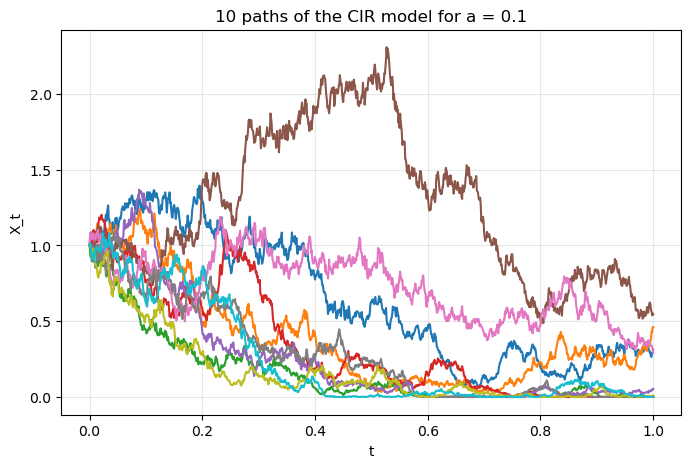

In [4]:
plt.figure(figsize=(8,5))

for i in range(10):
    X = CIR(0.1, 1, 0.001)
    plt.plot(t, X)

plt.title("10 paths of the CIR model for a = 0.1")
plt.xlabel("t")
plt.ylabel("X_t")
plt.grid(alpha=0.3)
plt.show()

### Discussion

For \(a = 0.1\), the drift term \((a - X_t)\) is relatively small and often negative when \(X_t > a\).
As a result, the process tends to move downward and approach zero.

Under the Euler discretization, some simulated paths may become negative.
Following the instructions, the remaining values of those paths are set equal to zero.

This behaviour can be observed in the plot, where several trajectories hit zero and remain flat afterwards.

### Case \(a=0.25\)

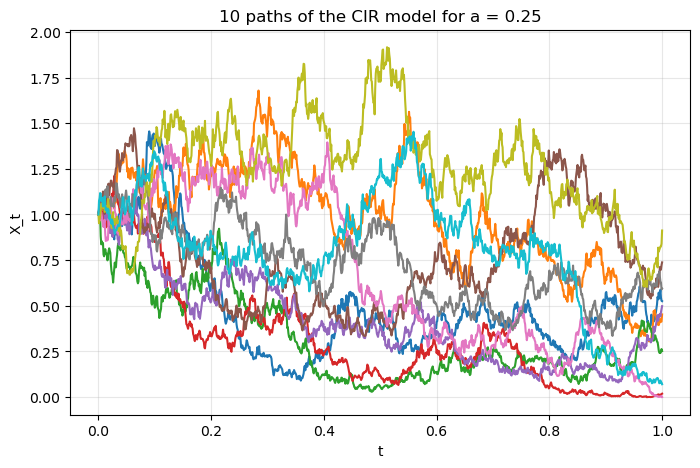

In [5]:
plt.figure(figsize=(8,5))

for i in range(10):
    X = CIR(0.25, 1, 0.001)
    plt.plot(t, X)

plt.title("10 paths of the CIR model for a = 0.25")
plt.xlabel("t")
plt.ylabel("X_t")
plt.grid(alpha=0.3)
plt.show()

### Discussion

For \(a = 0.25\), the drift term \((a - X_t)\) is stronger than in the previous case.
As a result, the paths tend to remain positive more often.

However, due to the stochastic fluctuations of the Brownian motion and the Euler discretization,
some trajectories may still approach or reach zero.

### Case \(a=10\)

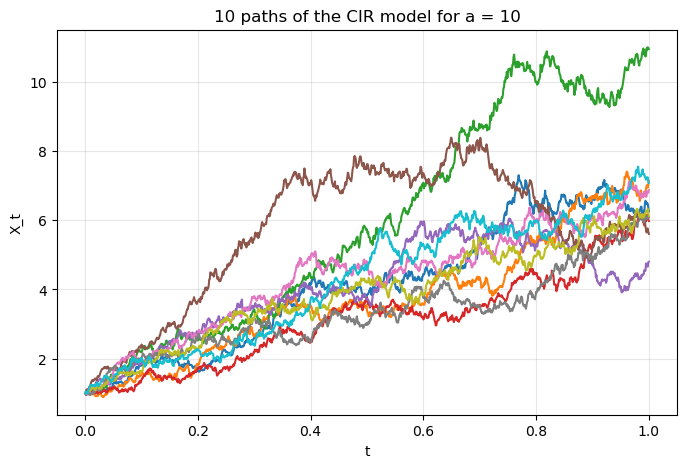

In [6]:
plt.figure(figsize=(8,5))

for i in range(10):
    X = CIR(10, 1, 0.001)
    plt.plot(t, X)

plt.title("10 paths of the CIR model for a = 10")
plt.xlabel("t")
plt.ylabel("X_t")
plt.grid(alpha=0.3)
plt.show()

### Discussion

For \(a = 10\), the drift term \((a - X_t)\) is much larger.
This strong positive drift pushes the process upward, so the simulated paths increase over time.

As a result, the process is very unlikely to approach zero or become negative.

## Part (b) – Proportion of paths that become negative

We simulate 1000 paths of the CIR process for each value of \(a\) and compute the proportion of paths that become negative at least once.

In [7]:
def becomes_negative(a, interval, step):

    n = int(interval/step)

    x = 1

    for i in range(n):

        if x < 0:
            return 1

        increment = (a - x) * step + np.sqrt(x) * np.sqrt(step) * np.random.standard_normal()
        x = x + increment

    if x < 0:
        return 1

    return 0

### Proportion for \(a = 0.1\)

In [8]:
count_01 = 0

for i in range(1000):
    count_01 += becomes_negative(0.1, 1, 0.001)

prop_01 = count_01 / 1000

print("Proportion of paths that become negative for a = 0.1:", prop_01)

Proportion of paths that become negative for a = 0.1: 0.233


### Proportion for \(a = 0.25\)

In [9]:
count_025 = 0

for i in range(1000):
    count_025 += becomes_negative(0.25, 1, 0.001)

prop_025 = count_025 / 1000

print("Proportion of paths that become negative for a = 0.25:", prop_025)

Proportion of paths that become negative for a = 0.25: 0.133


### Proportion for \(a = 10\)

In [10]:
count_10 = 0

for i in range(1000):
    count_10 += becomes_negative(10, 1, 0.001)

prop_10 = count_10 / 1000

print("Proportion of paths that become negative for a = 10:", prop_10)

Proportion of paths that become negative for a = 10: 0.0


### Interpretation of the results

From the simulations, we observe that the proportion of paths that become negative decreases as the parameter \(a\) increases.

For \(a = 0.1\), about 23.3% of the simulated paths become negative.  
For \(a = 0.25\), this proportion decreases to about 13.3%.  
For \(a = 10\), none of the simulated paths become negative.

This behavior can be explained by the drift term \(a - X_t\). When \(a\) is larger, the drift pushes the process upward, keeping the trajectories away from zero. As a result, the probability that the numerical Euler scheme produces negative values becomes smaller.

These results illustrate how the parameter \(a\) influences the stability and positivity of the CIR process.